# UniMiB Dataset Exploration

Notebook này thực hiện data exploration cho UniMiB SHAR (Smartphone-based HAR) dataset:
- Accelerometer signals (ax, ay, az) từ smartphone sensors
- Train/Val/Test splits


In [22]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Paths - Adjust based on notebook location (src/research/)
NOTEBOOK_DIR = Path.cwd()
# If running from src/research/, go up 2 levels to project root
if NOTEBOOK_DIR.name == 'research':
    BASE_DIR = NOTEBOOK_DIR.parent.parent
else:
    BASE_DIR = NOTEBOOK_DIR

DATA_DIR = BASE_DIR / "src" / "datasets" / "unimib"
UNIMIB_DIR = DATA_DIR / "UniMiB"

# Load class names from acc_names.npy
acc_names_path = UNIMIB_DIR / "acc_names.npy"
if acc_names_path.exists():
    acc_names = np.load(acc_names_path, allow_pickle=True)
    # Convert to dictionary with index as key
    # acc_names is typically a numpy array of strings
    if isinstance(acc_names, np.ndarray):

        CLASS_NAMES = {i: str(name[0]) for i, name in enumerate(acc_names[1])}
    
    print(f"Loaded {len(CLASS_NAMES)} class names from {acc_names_path}")
    print(f"Class names: {CLASS_NAMES}")
else:
    # Fallback to hardcoded names if file doesn't exist
    print(f"Warning: {acc_names_path} not found, using hardcoded class names")
    CLASS_NAMES = {
        0: 'StandingUpFS',
        1: 'StandingUpFL',
        2: 'Walking',
        3: 'Running',
        4: 'GoingUpS',
        5: 'Jumping',
        6: 'GoingDownS',
        7: 'LyingDownFS',
        8: 'SittingDown'
    }

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Base directory: {BASE_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Data directory exists: {DATA_DIR.exists()}")



Loaded 17 class names from c:\Users\KietVu\Testplace\test\biodiffusion\src\datasets\unimib\UniMiB\acc_names.npy
Class names: {0: 'StandingUpFS', 1: 'StandingUpFL', 2: 'Walking', 3: 'Running', 4: 'GoingUpS', 5: 'Jumping', 6: 'GoingDownS', 7: 'LyingDownFS', 8: 'SittingDown', 9: 'FallingForw', 10: 'FallingRight', 11: 'FallingBack', 12: 'HittingObstacle', 13: 'FallingWithPS', 14: 'FallingBackSC', 15: 'Syncope', 16: 'FallingLeft'}
Notebook directory: c:\Users\KietVu\Testplace\test\biodiffusion\src\research
Base directory: c:\Users\KietVu\Testplace\test\biodiffusion
Data directory: c:\Users\KietVu\Testplace\test\biodiffusion\src\datasets\unimib
Data directory exists: True


## 1. Load Datasets


In [23]:
# Load UniMiB datasets
print("Loading UniMiB datasets...")
unimib_train = pd.read_csv(DATA_DIR / "unimib_train.csv")
unimib_val = pd.read_csv(DATA_DIR / "unimib_val.csv")
unimib_test = pd.read_csv(DATA_DIR / "unimib_test.csv")

# Filter: chỉ giữ lại các record có label <= 8 (ADLs only)
print("\nFiltering datasets: chỉ giữ lại labels <= 8 (ADLs)...")
train_before = len(unimib_train)
val_before = len(unimib_val)
test_before = len(unimib_test)

unimib_train = unimib_train[unimib_train['label'] <= 9].copy()
unimib_val = unimib_val[unimib_val['label'] <= 9].copy()
unimib_test = unimib_test[unimib_test['label'] <= 9].copy()

print(f"Train: {train_before:,} -> {len(unimib_train):,} records (removed {train_before - len(unimib_train):,})")
print(f"Val: {val_before:,} -> {len(unimib_val):,} records (removed {val_before - len(unimib_val):,})")
print(f"Test: {test_before:,} -> {len(unimib_test):,} records (removed {test_before - len(unimib_test):,})")

print(f"\nUniMiB Train shape: {unimib_train.shape}")
print(f"UniMiB Val shape: {unimib_val.shape}")
print(f"UniMiB Test shape: {unimib_test.shape}")

# Display first few rows
print("\nFirst few rows of train dataset:")
print(unimib_train.head(10))


Loading UniMiB datasets...

Filtering datasets: chỉ giữ lại labels <= 8 (ADLs)...
Train: 1,421,967 -> 933,180 records (removed 488,787)
Val: 177,727 -> 116,723 records (removed 61,004)
Test: 177,727 -> 116,723 records (removed 61,004)

UniMiB Train shape: (933180, 7)
UniMiB Val shape: (116723, 7)
UniMiB Test shape: (116723, 7)

First few rows of train dataset:
   ID  t        ax        ay        az  label       mag
0   0  0  1.463904  0.267338 -0.240852      1 -0.448149
1   0  1  1.407320  0.321725 -0.271622      1 -0.466154
2   0  2  1.399128  0.337630 -0.347673      1 -0.445171
3   0  3  1.492430  0.334661 -0.307134      1 -0.356161
4   0  4  1.549750  0.300181 -0.192982      1 -0.338196
5   0  5  1.583914  0.205335 -0.126676      1 -0.363472
6   0  6  1.618105  0.095286 -0.172656      1 -0.360203
7   0  7  1.655539  0.055428 -0.208554      1 -0.319973
8   0  8  1.671424  0.047886 -0.160210      1 -0.309323
9   0  9  1.673855  0.027274 -0.129925      1 -0.313224


## 2. Dataset Overview & Basic Statistics


In [ ]:
# UniMiB Dataset Structure
print("=" * 60)
print("UNIMIB DATASET STRUCTURE")
print("=" * 60)

# Convert labels from 1-9 to 0-8 if needed
if unimib_train['label'].min() > 0:
    unimib_train['label'] = unimib_train['label'] - 1
    unimib_val['label'] = unimib_val['label'] - 1
    unimib_test['label'] = unimib_test['label'] - 1

# Group by ID to create samples
def group_by_id(df):
    """Group data by ID to create samples"""
    grouped = df.groupby('ID')
    samples = []
    labels_list = []
    ids_list = []
    
    for id_val, group in grouped:
        # Extract ax, ay, az channels
        ax = group['ax'].values
        ay = group['ay'].values
        az = group['az'].values
        
        # Get label (all rows in group have same label)
        label = group['label'].iloc[0]
        
        # Ensure sequence length is 128
        seq_len = len(ax)
        if seq_len >= 128:
            ax = ax[:128]
            ay = ay[:128]
            az = az[:128]
        else:
            ax = np.pad(ax, (0, 128 - seq_len), mode='constant')
            ay = np.pad(ay, (0, 128 - seq_len), mode='constant')
            az = np.pad(az, (0, 128 - seq_len), mode='constant')
        
        # Stack into (3, 128) shape
        sample = np.stack([ax, ay, az], axis=0)  # Shape: (3, 128)
        samples.append(sample)
        labels_list.append(label)
        ids_list.append(id_val)
    
    return np.array(samples), np.array(labels_list), np.array(ids_list)

# Process datasets
train_signals, train_labels, train_ids = group_by_id(unimib_train)
val_signals, val_labels, val_ids = group_by_id(unimib_val)
test_signals, test_labels, test_ids = group_by_id(unimib_test)

print(f"\nTrain signals shape: {train_signals.shape}")  # (n_samples, 3, 128)
print(f"Val signals shape: {val_signals.shape}")
print(f"Test signals shape: {test_signals.shape}")

print(f"\nLabel range: {min(train_labels.min(), val_labels.min(), test_labels.min())} - {max(train_labels.max(), val_labels.max(), test_labels.max())}")

# Check for missing values
print(f"\nMissing values in train signals: {np.isnan(train_signals).sum()}")
print(f"Missing values in val signals: {np.isnan(val_signals).sum()}")
print(f"Missing values in test signals: {np.isnan(test_signals).sum()}")

# Signal statistics (across all channels)
print(f"\nSignal value range (train):")
print(f"  Min: {train_signals.min():.6f}")
print(f"  Max: {train_signals.max():.6f}")
print(f"  Mean: {train_signals.mean():.6f}")
print(f"  Std: {train_signals.std():.6f}")

print(f"\nSignal value range (val):")
print(f"  Min: {val_signals.min():.6f}")
print(f"  Max: {val_signals.max():.6f}")
print(f"  Mean: {val_signals.mean():.6f}")
print(f"  Std: {val_signals.std():.6f}")

print(f"\nSignal value range (test):")
print(f"  Min: {test_signals.min():.6f}")
print(f"  Max: {test_signals.max():.6f}")
print(f"  Mean: {test_signals.mean():.6f}")
print(f"  Std: {test_signals.std():.6f}")

# Statistics per channel
print(f"\nPer-channel statistics (train):")
for i, channel_name in enumerate(['ax', 'ay', 'az']):
    channel_data = train_signals[:, i, :]
    print(f"  {channel_name}: mean={channel_data.mean():.6f}, std={channel_data.std():.6f}, "
          f"min={channel_data.min():.6f}, max={channel_data.max():.6f}")


UNIMIB DATASET STRUCTURE

Train signals shape: (6180, 3, 128)
Val signals shape: (773, 3, 128)
Test signals shape: (773, 3, 128)

Label range: 0 - 8

Missing values in train signals: 0
Missing values in val signals: 0
Missing values in test signals: 0

Signal value range (train):
  Min: -4.177854
  Max: 4.303429
  Mean: -0.021553
  Std: 0.940145

Signal value range (val):
  Min: -4.177854
  Max: 4.303429
  Mean: -0.033690
  Std: 0.935991

Signal value range (test):
  Min: -4.177854
  Max: 4.303429
  Mean: -0.007084
  Std: 0.938090

Per-channel statistics (train):
  ax: mean=0.031857, std=0.897659, min=-3.913222, max=3.824166
  ay: mean=-0.004412, std=1.104510, min=-2.356087, max=2.266242
  az: mean=-0.092104, std=0.785977, min=-4.177854, max=4.303429


## 3. Class Distribution Analysis


UNIMIB CLASS DISTRIBUTION

Train set class distribution:
  Class 0 (StandingUpFS):    228 ( 3.69%)
  Class 1 (StandingUpFL):    317 ( 5.13%)
  Class 2 (Walking):   1342 (21.72%)
  Class 3 (Running):   1556 (25.18%)
  Class 4 (GoingUpS):    726 (11.75%)
  Class 5 (Jumping):    597 ( 9.66%)
  Class 6 (GoingDownS):   1024 (16.57%)
  Class 7 (LyingDownFS):    233 ( 3.77%)
  Class 8 (SittingDown):    157 ( 2.54%)

Val set class distribution:
  Class 0 (StandingUpFS):     29 ( 3.75%)
  Class 1 (StandingUpFL):     40 ( 5.17%)
  Class 2 (Walking):    168 (21.73%)
  Class 3 (Running):    194 (25.10%)
  Class 4 (GoingUpS):     91 (11.77%)
  Class 5 (Jumping):     74 ( 9.57%)
  Class 6 (GoingDownS):    128 (16.56%)
  Class 7 (LyingDownFS):     29 ( 3.75%)
  Class 8 (SittingDown):     20 ( 2.59%)

Test set class distribution:
  Class 0 (StandingUpFS):     29 ( 3.75%)
  Class 1 (StandingUpFL):     40 ( 5.17%)
  Class 2 (Walking):    168 (21.73%)
  Class 3 (Running):    194 (25.10%)
  Class 4 (Going

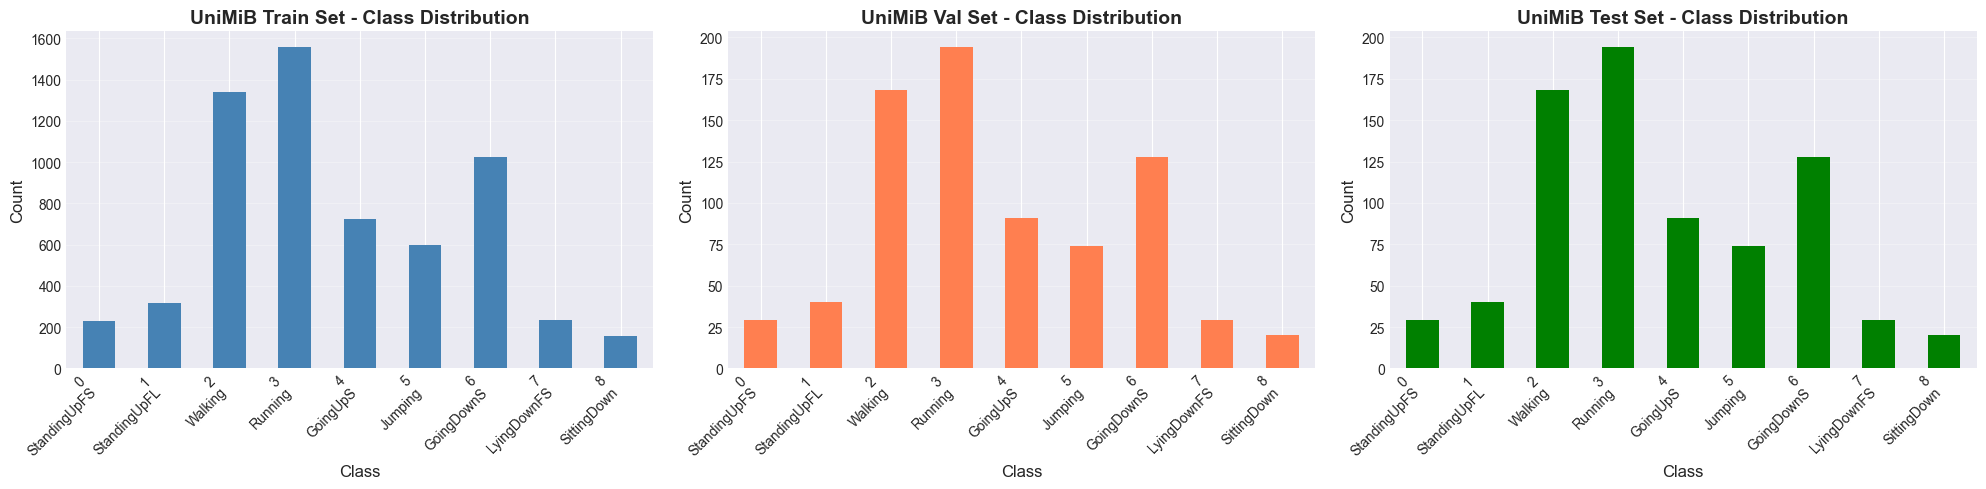

In [25]:
# Class distribution in UniMiB datasets
print("=" * 60)
print("UNIMIB CLASS DISTRIBUTION")
print("=" * 60)

# Train set
train_class_counts = pd.Series(train_labels).value_counts().sort_index()
print("\nTrain set class distribution:")
for class_id in sorted(train_class_counts.index):
    if class_id > 8:
        break
    count = train_class_counts[class_id]
    percentage = (count / len(train_labels)) * 100
    print(f"  Class {class_id} ({CLASS_NAMES[class_id]}): {count:6d} ({percentage:5.2f}%)")

# Val set
val_class_counts = pd.Series(val_labels).value_counts().sort_index()
print("\nVal set class distribution:")
for class_id in sorted(val_class_counts.index):
    if class_id > 8:
        break
    count = val_class_counts[class_id]
    percentage = (count / len(val_labels)) * 100
    print(f"  Class {class_id} ({CLASS_NAMES[class_id]}): {count:6d} ({percentage:5.2f}%)")

# Test set
test_class_counts = pd.Series(test_labels).value_counts().sort_index()
print("\nTest set class distribution:")
for class_id in sorted(test_class_counts.index):
    if class_id > 8:
        break
    count = test_class_counts[class_id]
    percentage = (count / len(test_labels)) * 100
    print(f"  Class {class_id} ({CLASS_NAMES[class_id]}): {count:6d} ({percentage:5.2f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Train set
train_class_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('UniMiB Train Set - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in sorted(train_class_counts.index)], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Val set
val_class_counts.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('UniMiB Val Set - Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in sorted(val_class_counts.index)], rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Test set
test_class_counts.plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('UniMiB Test Set - Class Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Class', fontsize=12)
axes[2].set_ylabel('Count', fontsize=12)
axes[2].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in sorted(test_class_counts.index)], rotation=45, ha='right')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


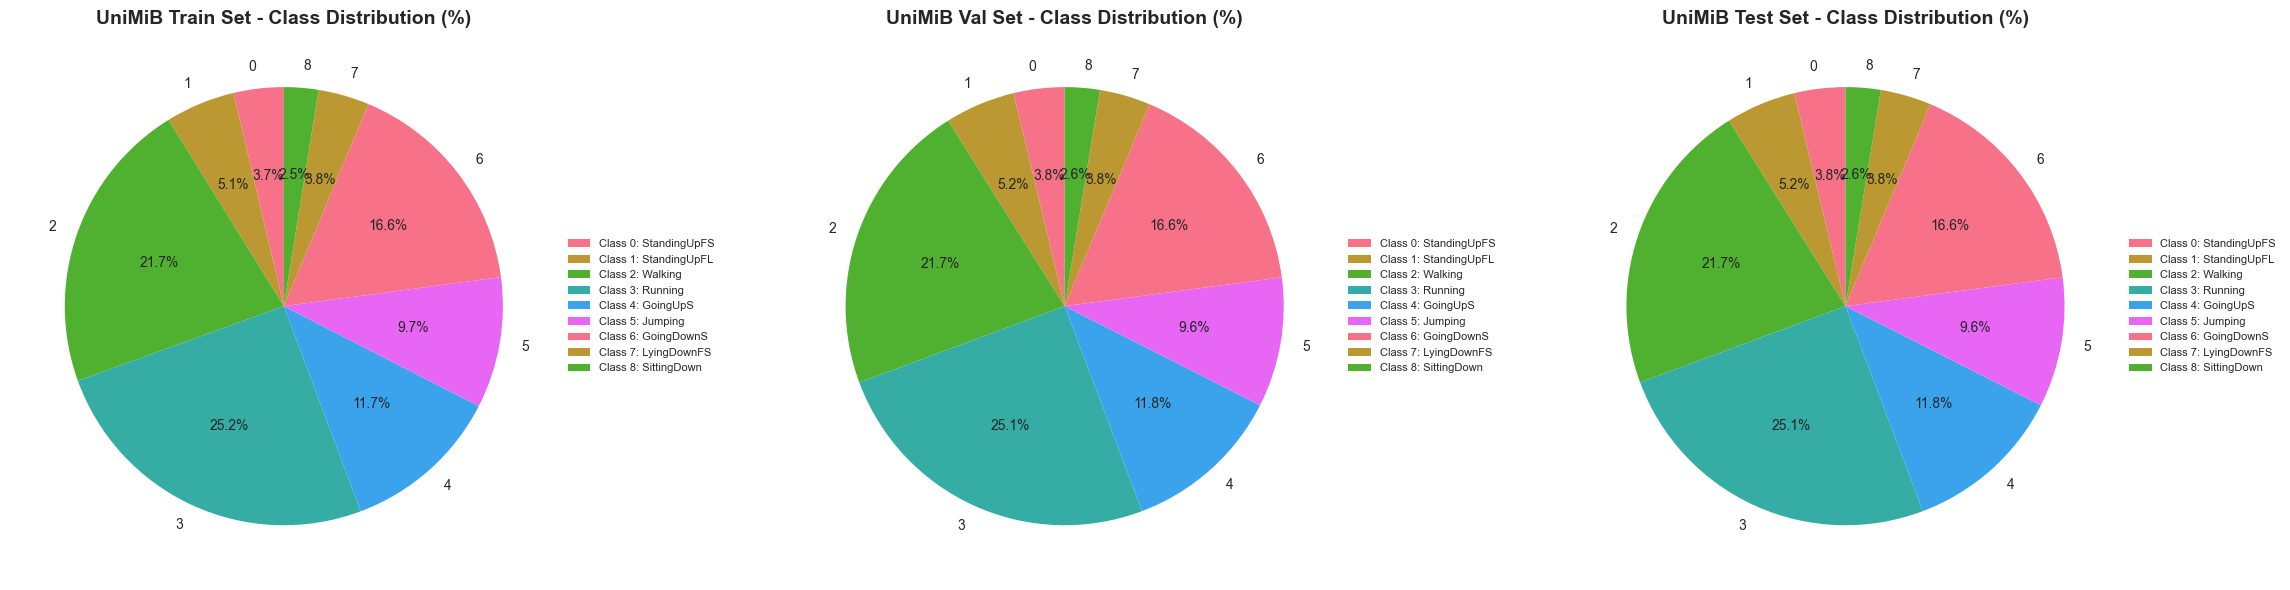

In [ ]:
# Pie charts for class distribution
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Train set pie chart
train_class_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90)
axes[0].set_title('UniMiB Train Set - Class Distribution (%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')
axes[0].legend([f"Class {i}: {CLASS_NAMES[i]}" for i in sorted(train_class_counts.index)], 
               loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# Val set pie chart
val_class_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('UniMiB Val Set - Class Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].legend([f"Class {i}: {CLASS_NAMES[i]}" for i in sorted(val_class_counts.index)], 
               loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# Test set pie chart
test_class_counts.plot(kind='pie', ax=axes[2], autopct='%1.1f%%', startangle=90)
axes[2].set_title('UniMiB Test Set - Class Distribution (%)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')
axes[2].legend([f"Class {i}: {CLASS_NAMES[i]}" for i in sorted(test_class_counts.index)], 
               loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()


## 4. Signal Visualization


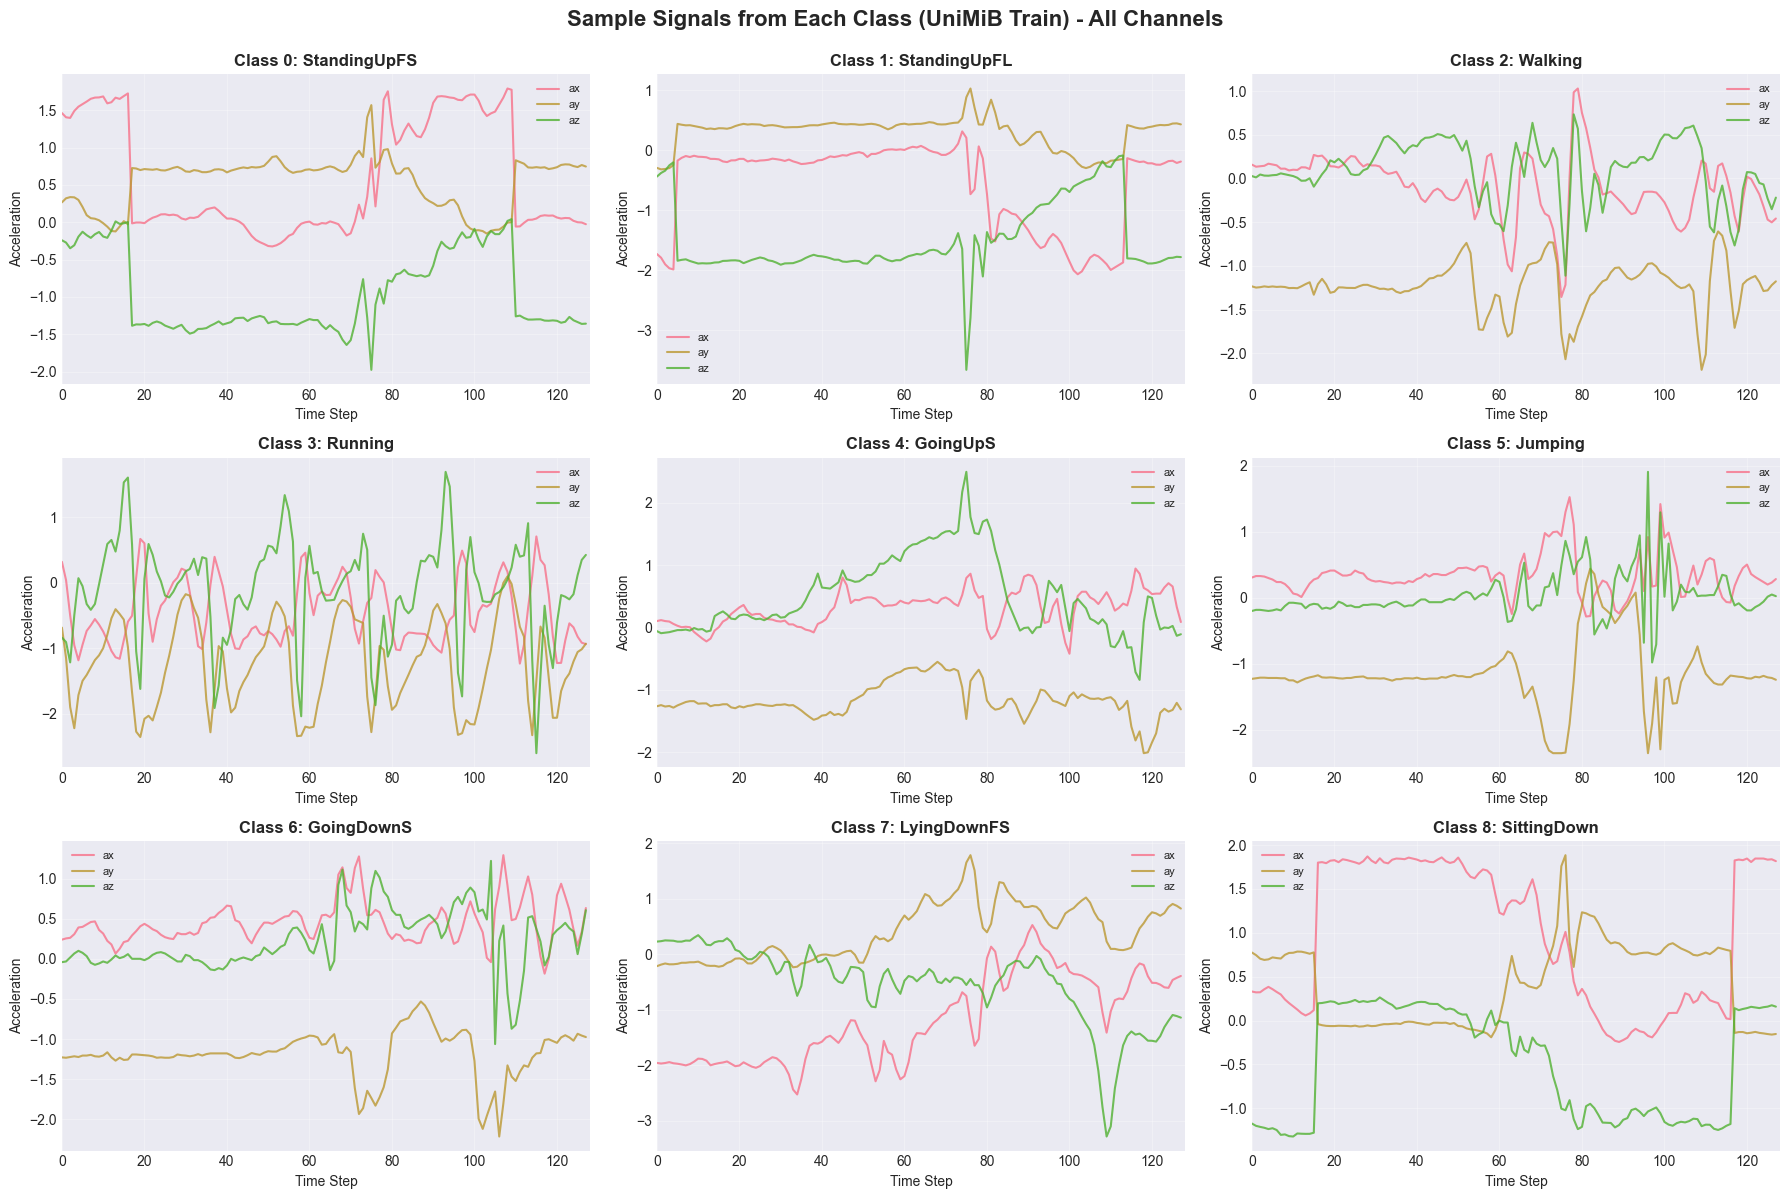

In [27]:
# Visualize sample signals from each class (Train) - All 3 channels
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for class_id in range(9):
    # Get first sample of each class
    class_indices = np.where(train_labels == class_id)[0]
    if len(class_indices) > 0:
        sample_idx = class_indices[0]
        signal = train_signals[sample_idx]  # Shape: (3, 128)
        
        # Plot all 3 channels
        time_steps = np.arange(128)
        axes[class_id].plot(time_steps, signal[0], label='ax', linewidth=1.5, alpha=0.8)
        axes[class_id].plot(time_steps, signal[1], label='ay', linewidth=1.5, alpha=0.8)
        axes[class_id].plot(time_steps, signal[2], label='az', linewidth=1.5, alpha=0.8)
        axes[class_id].set_title(f'Class {class_id}: {CLASS_NAMES[class_id]}', fontsize=12, fontweight='bold')
        axes[class_id].set_xlabel('Time Step', fontsize=10)
        axes[class_id].set_ylabel('Acceleration', fontsize=10)
        axes[class_id].legend(fontsize=8)
        axes[class_id].grid(True, alpha=0.3)
        axes[class_id].set_xlim(0, 128)

plt.suptitle('Sample Signals from Each Class (UniMiB Train) - All Channels', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


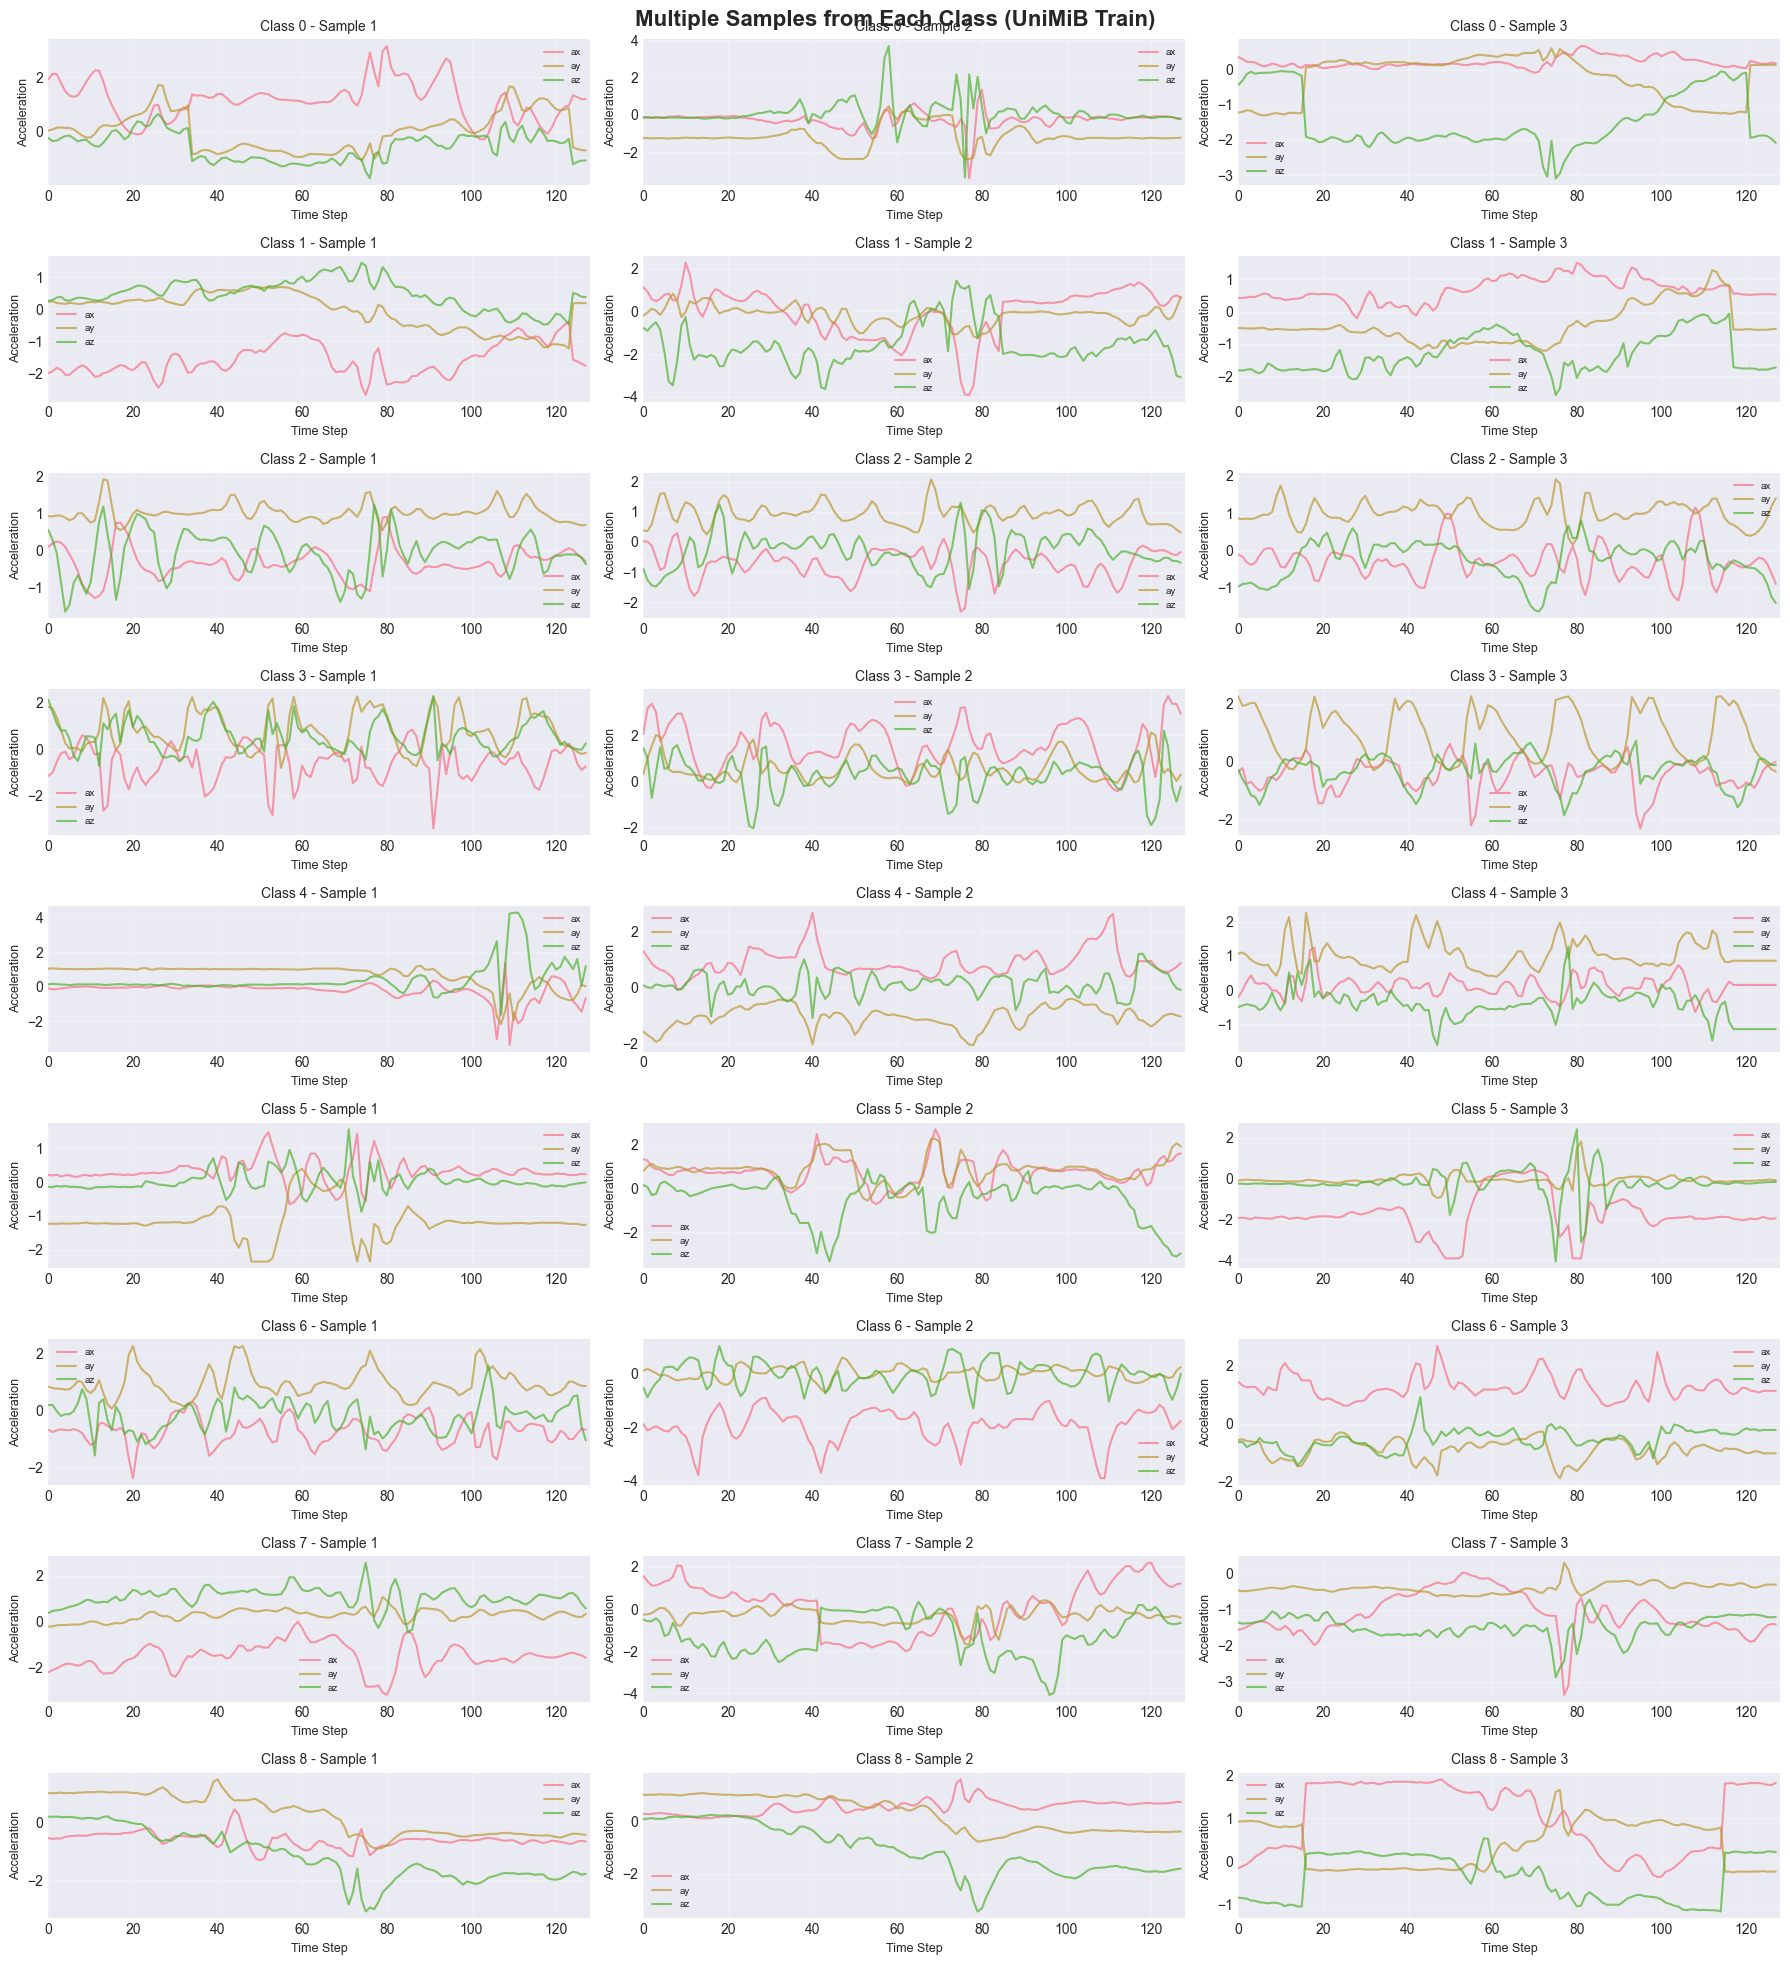

In [28]:
# Visualize multiple samples from each class - Separate channels
fig, axes = plt.subplots(9, 3, figsize=(18, 20))

for class_id in range(9):
    class_indices = np.where(train_labels == class_id)[0]
    if len(class_indices) > 0:
        # Plot 3 random samples from each class
        sample_indices = np.random.choice(class_indices, min(3, len(class_indices)), replace=False)
        
        for i, sample_idx in enumerate(sample_indices):
            signal = train_signals[sample_idx]  # Shape: (3, 128)
            time_steps = np.arange(128)
            
            # Plot each channel separately
            axes[class_id, i].plot(time_steps, signal[0], label='ax', linewidth=1.5, alpha=0.7)
            axes[class_id, i].plot(time_steps, signal[1], label='ay', linewidth=1.5, alpha=0.7)
            axes[class_id, i].plot(time_steps, signal[2], label='az', linewidth=1.5, alpha=0.7)
            axes[class_id, i].set_title(f'Class {class_id} - Sample {i+1}', fontsize=10)
            axes[class_id, i].set_xlabel('Time Step', fontsize=9)
            axes[class_id, i].set_ylabel('Acceleration', fontsize=9)
            axes[class_id, i].legend(fontsize=7)
            axes[class_id, i].grid(True, alpha=0.3)
            axes[class_id, i].set_xlim(0, 128)

plt.suptitle('Multiple Samples from Each Class (UniMiB Train)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


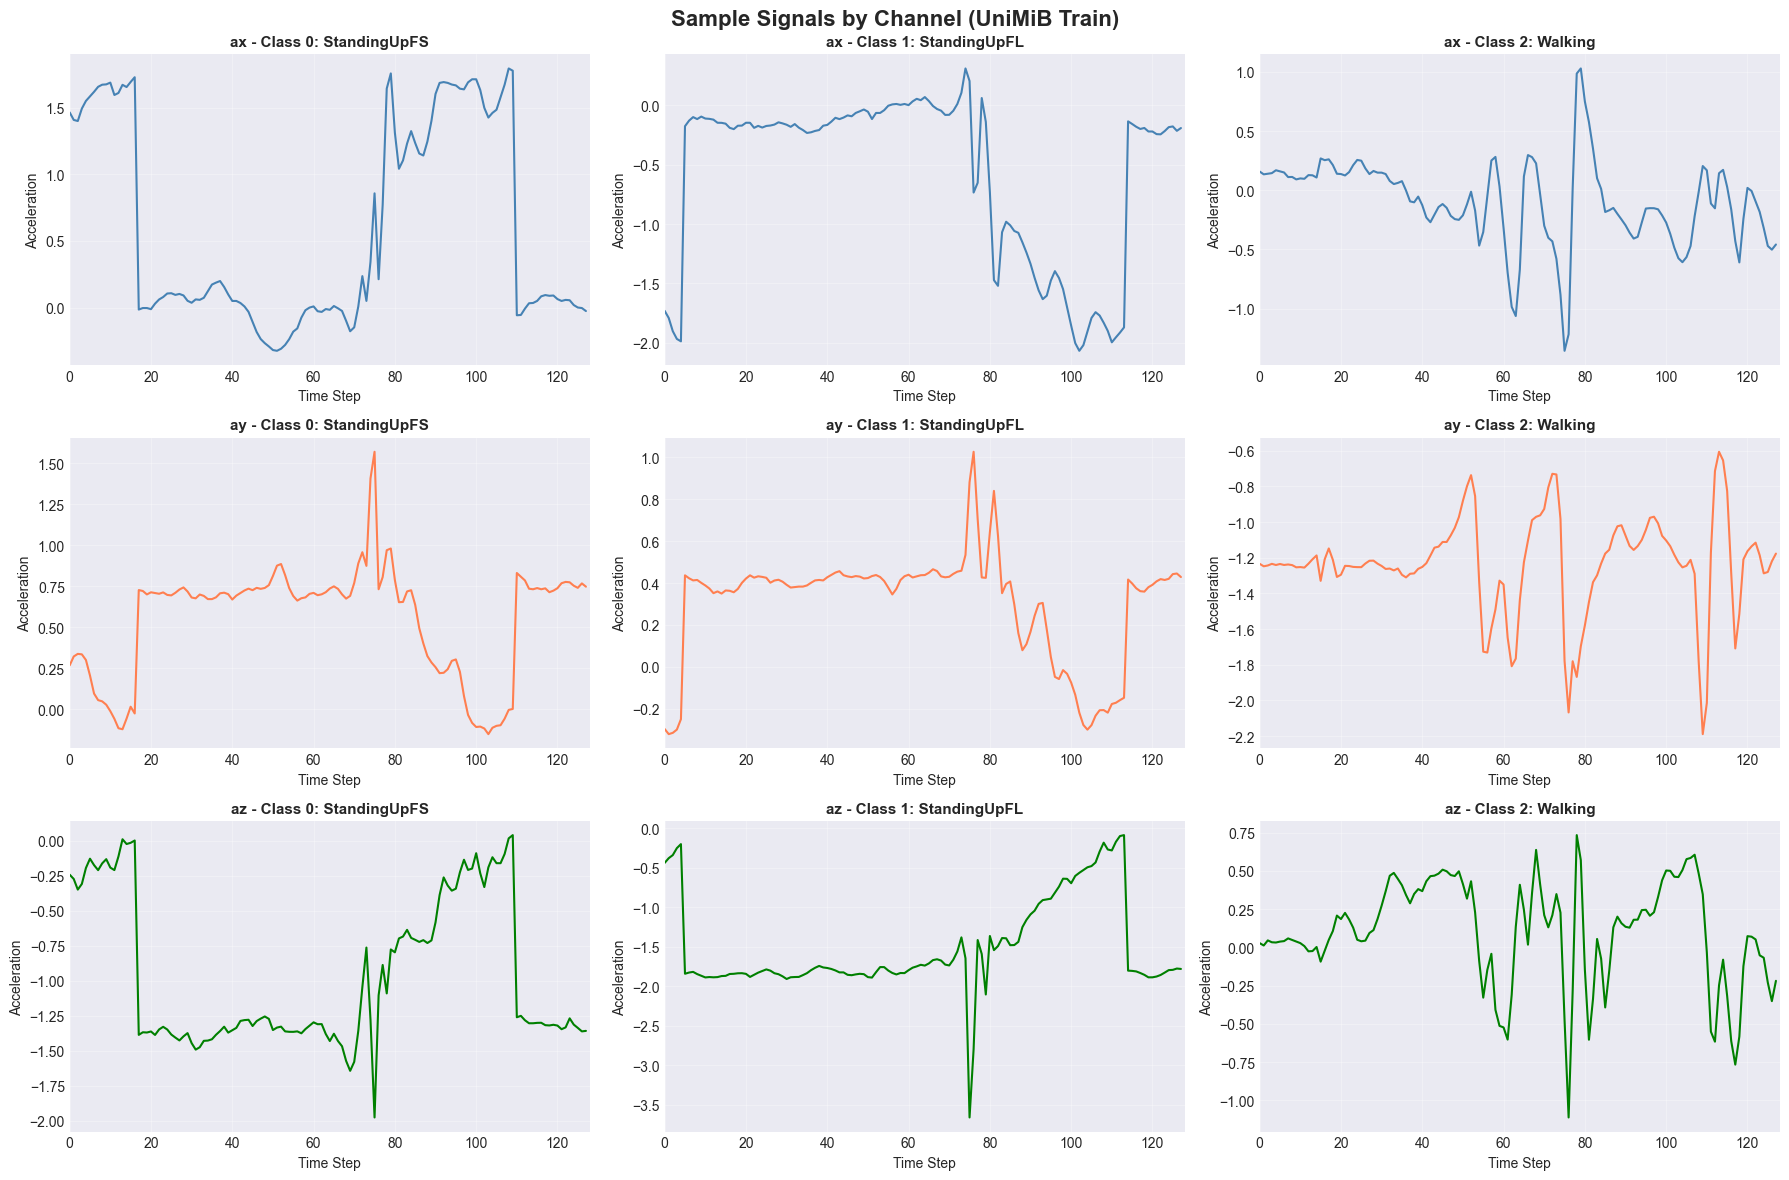

In [29]:
# Visualize signals by channel separately
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
channel_names = ['ax', 'ay', 'az']
channel_colors = ['steelblue', 'coral', 'green']

for channel_idx in range(3):
    for class_id in range(3):
        class_indices = np.where(train_labels == class_id)[0]
        if len(class_indices) > 0:
            sample_idx = class_indices[0]
            signal = train_signals[sample_idx, channel_idx, :]
            
            axes[channel_idx, class_id].plot(signal, linewidth=1.5, color=channel_colors[channel_idx])
            axes[channel_idx, class_id].set_title(f'{channel_names[channel_idx]} - Class {class_id}: {CLASS_NAMES[class_id]}', 
                                                   fontsize=11, fontweight='bold')
            axes[channel_idx, class_id].set_xlabel('Time Step', fontsize=10)
            axes[channel_idx, class_id].set_ylabel('Acceleration', fontsize=10)
            axes[channel_idx, class_id].grid(True, alpha=0.3)
            axes[channel_idx, class_id].set_xlim(0, 128)

plt.suptitle('Sample Signals by Channel (UniMiB Train)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Statistical Analysis by Class


In [30]:
# Calculate statistics for each class
print("=" * 60)
print("STATISTICAL ANALYSIS BY CLASS (UniMiB Train)")
print("=" * 60)

class_stats = []
for class_id in range(9):
    class_indices = np.where(train_labels == class_id)[0]
    if len(class_indices) > 0:
        class_signals = train_signals[class_indices]  # Shape: (n_samples, 3, 128)
        
        # Flatten across all channels and timesteps
        class_signals_flat = class_signals.flatten()
        
        stats = {
            'Class': class_id,
            'Class Name': CLASS_NAMES[class_id],
            'Count': len(class_indices),
            'Mean': class_signals_flat.mean(),
            'Std': class_signals_flat.std(),
            'Min': class_signals_flat.min(),
            'Max': class_signals_flat.max(),
            'Median': np.median(class_signals_flat),
            'Q25': np.percentile(class_signals_flat, 25),
            'Q75': np.percentile(class_signals_flat, 75)
        }
        
        # Per-channel statistics
        for ch_idx, ch_name in enumerate(['ax', 'ay', 'az']):
            ch_data = class_signals[:, ch_idx, :].flatten()
            stats[f'{ch_name}_mean'] = ch_data.mean()
            stats[f'{ch_name}_std'] = ch_data.std()
        
        class_stats.append(stats)
        
        print(f"\nClass {class_id} ({CLASS_NAMES[class_id]}):")
        print(f"  Count: {stats['Count']}")
        print(f"  Mean: {stats['Mean']:.6f}")
        print(f"  Std: {stats['Std']:.6f}")
        print(f"  Min: {stats['Min']:.6f}")
        print(f"  Max: {stats['Max']:.6f}")
        print(f"  Median: {stats['Median']:.6f}")
        print(f"  Per-channel means: ax={stats['ax_mean']:.4f}, ay={stats['ay_mean']:.4f}, az={stats['az_mean']:.4f}")

# Create DataFrame for easier visualization
stats_df = pd.DataFrame(class_stats)
print("\n" + "=" * 60)
print("Summary Statistics Table:")
print("=" * 60)
display_cols = ['Class', 'Class Name', 'Count', 'Mean', 'Std', 'Min', 'Max', 'ax_mean', 'ay_mean', 'az_mean']
print(stats_df[display_cols].to_string(index=False))


STATISTICAL ANALYSIS BY CLASS (UniMiB Train)

Class 0 (StandingUpFS):
  Count: 228
  Mean: -0.217790
  Std: 0.957698
  Min: -4.177854
  Max: 4.303429
  Median: -0.149753
  Per-channel means: ax=0.0091, ay=-0.4046, az=-0.2579

Class 1 (StandingUpFL):
  Count: 317
  Mean: -0.016822
  Std: 1.018387
  Min: -4.177854
  Max: 4.303429
  Median: 0.074687
  Per-channel means: ax=0.2126, ay=0.1237, az=-0.3867

Class 2 (Walking):
  Count: 1342
  Mean: -0.068443
  Std: 0.845612
  Min: -4.164935
  Max: 4.303429
  Median: -0.011858
  Per-channel means: ax=0.0511, ay=-0.2319, az=-0.0246

Class 3 (Running):
  Count: 1556
  Mean: 0.009826
  Std: 1.018945
  Min: -4.158754
  Max: 4.303429
  Median: -0.001781
  Per-channel means: ax=-0.0100, ay=0.0540, az=-0.0145

Class 4 (GoingUpS):
  Count: 726
  Mean: -0.000865
  Std: 0.894495
  Min: -4.177854
  Max: 4.303429
  Median: 0.025407
  Per-channel means: ax=0.0872, ay=0.0177, az=-0.1075

Class 5 (Jumping):
  Count: 597
  Mean: 0.024479
  Std: 0.957944
  Min:

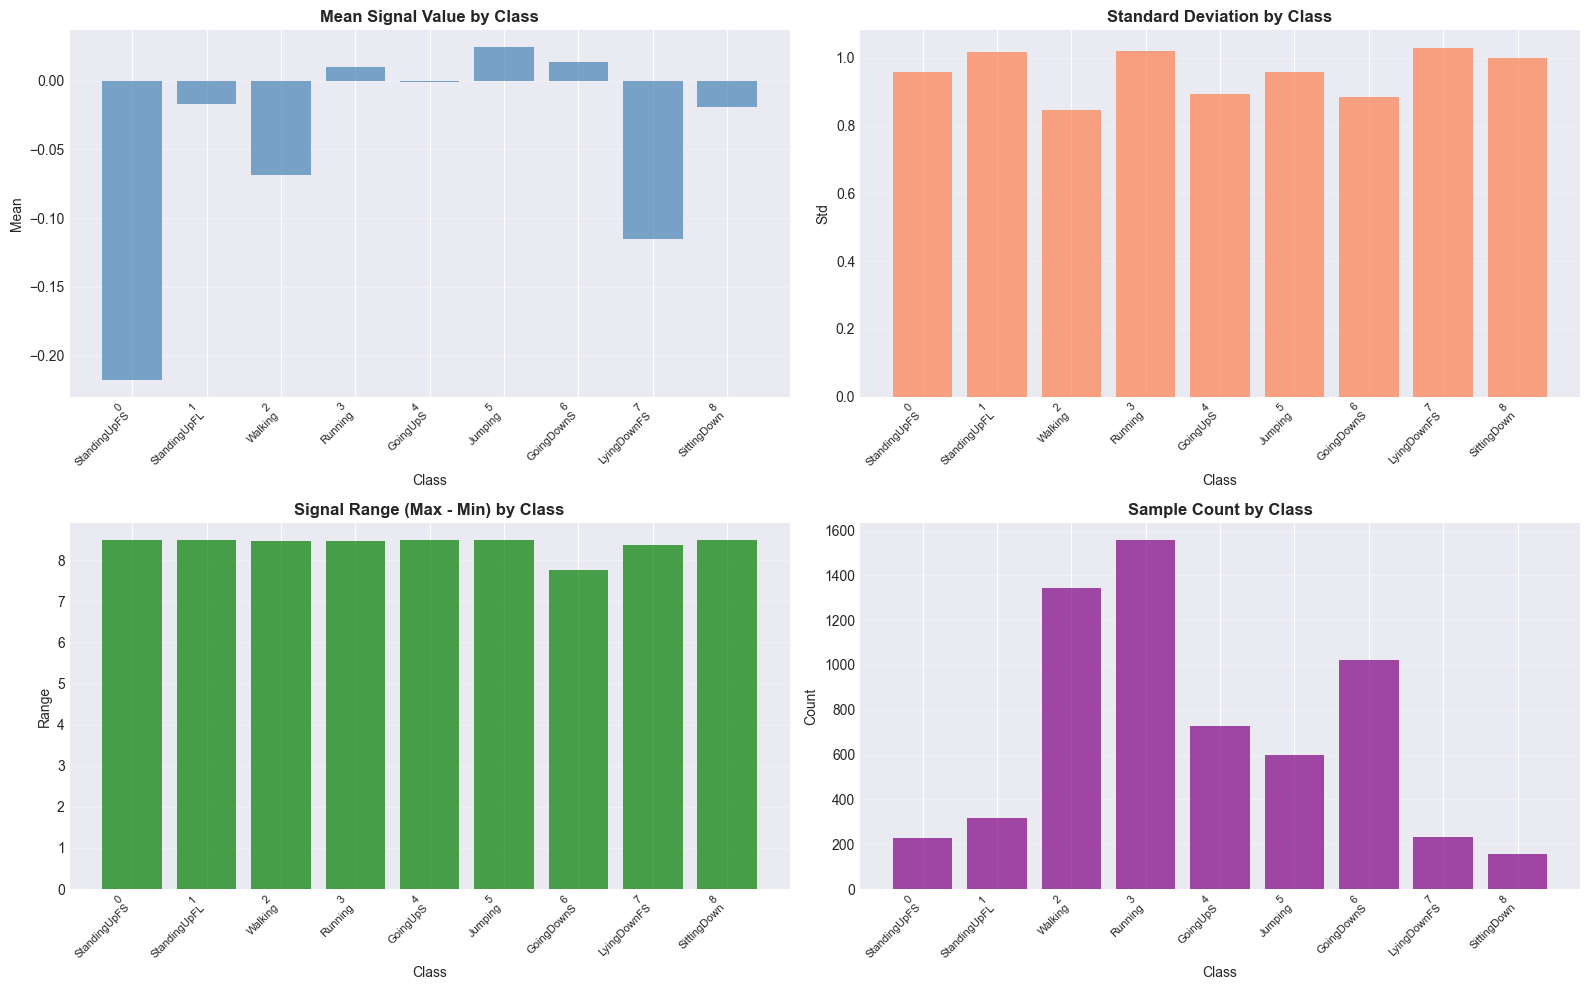

In [31]:
# Visualize statistics by class
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Mean values by class
axes[0, 0].bar(stats_df['Class'], stats_df['Mean'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Mean Signal Value by Class', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Class', fontsize=10)
axes[0, 0].set_ylabel('Mean', fontsize=10)
axes[0, 0].set_xticks(stats_df['Class'])
axes[0, 0].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in stats_df['Class']], rotation=45, ha='right', fontsize=8)
axes[0, 0].grid(axis='y', alpha=0.3)

# Std values by class
axes[0, 1].bar(stats_df['Class'], stats_df['Std'], color='coral', alpha=0.7)
axes[0, 1].set_title('Standard Deviation by Class', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Class', fontsize=10)
axes[0, 1].set_ylabel('Std', fontsize=10)
axes[0, 1].set_xticks(stats_df['Class'])
axes[0, 1].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in stats_df['Class']], rotation=45, ha='right', fontsize=8)
axes[0, 1].grid(axis='y', alpha=0.3)

# Range (Max - Min) by class
axes[1, 0].bar(stats_df['Class'], stats_df['Max'] - stats_df['Min'], color='green', alpha=0.7)
axes[1, 0].set_title('Signal Range (Max - Min) by Class', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Class', fontsize=10)
axes[1, 0].set_ylabel('Range', fontsize=10)
axes[1, 0].set_xticks(stats_df['Class'])
axes[1, 0].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in stats_df['Class']], rotation=45, ha='right', fontsize=8)
axes[1, 0].grid(axis='y', alpha=0.3)

# Count by class
axes[1, 1].bar(stats_df['Class'], stats_df['Count'], color='purple', alpha=0.7)
axes[1, 1].set_title('Sample Count by Class', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Class', fontsize=10)
axes[1, 1].set_ylabel('Count', fontsize=10)
axes[1, 1].set_xticks(stats_df['Class'])
axes[1, 1].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in stats_df['Class']], rotation=45, ha='right', fontsize=8)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


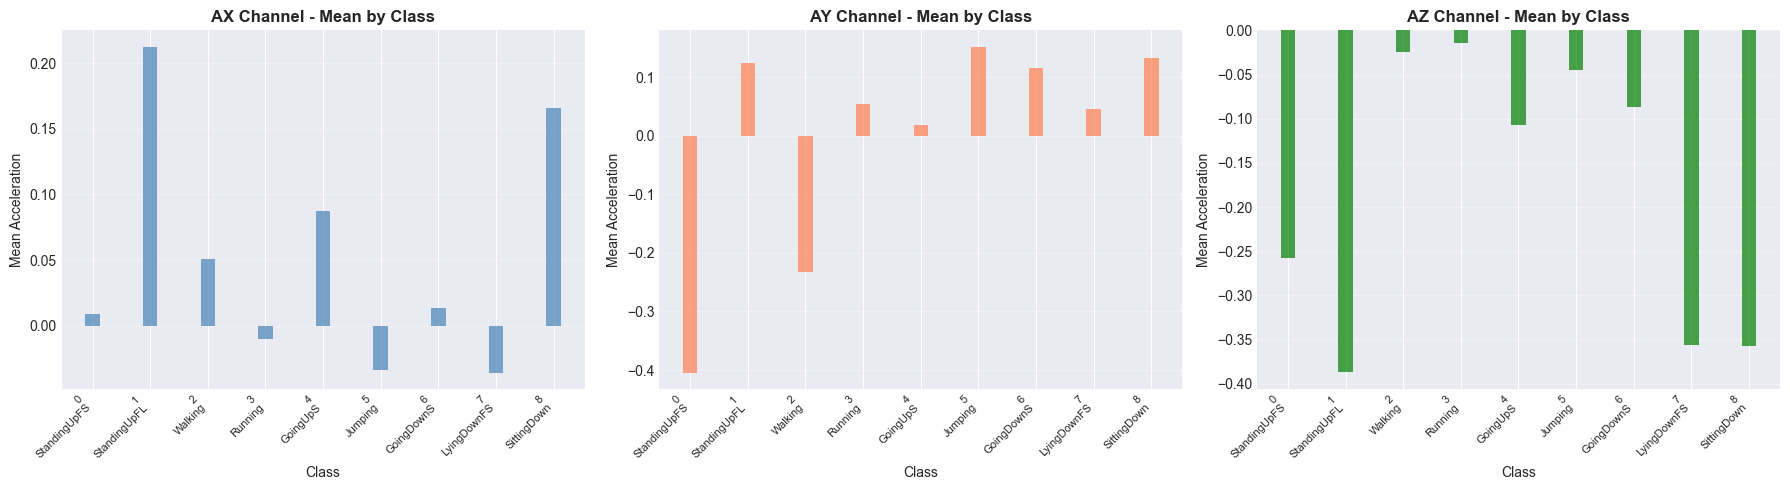

In [32]:
# Per-channel mean comparison by class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(stats_df))
width = 0.25

for i, (ch_name, color) in enumerate(zip(['ax', 'ay', 'az'], ['steelblue', 'coral', 'green'])):
    axes[i].bar(x, stats_df[f'{ch_name}_mean'], color=color, alpha=0.7, width=width)
    axes[i].set_title(f'{ch_name.upper()} Channel - Mean by Class', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Class', fontsize=10)
    axes[i].set_ylabel('Mean Acceleration', fontsize=10)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in stats_df['Class']], rotation=45, ha='right', fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Signal Distribution Analysis


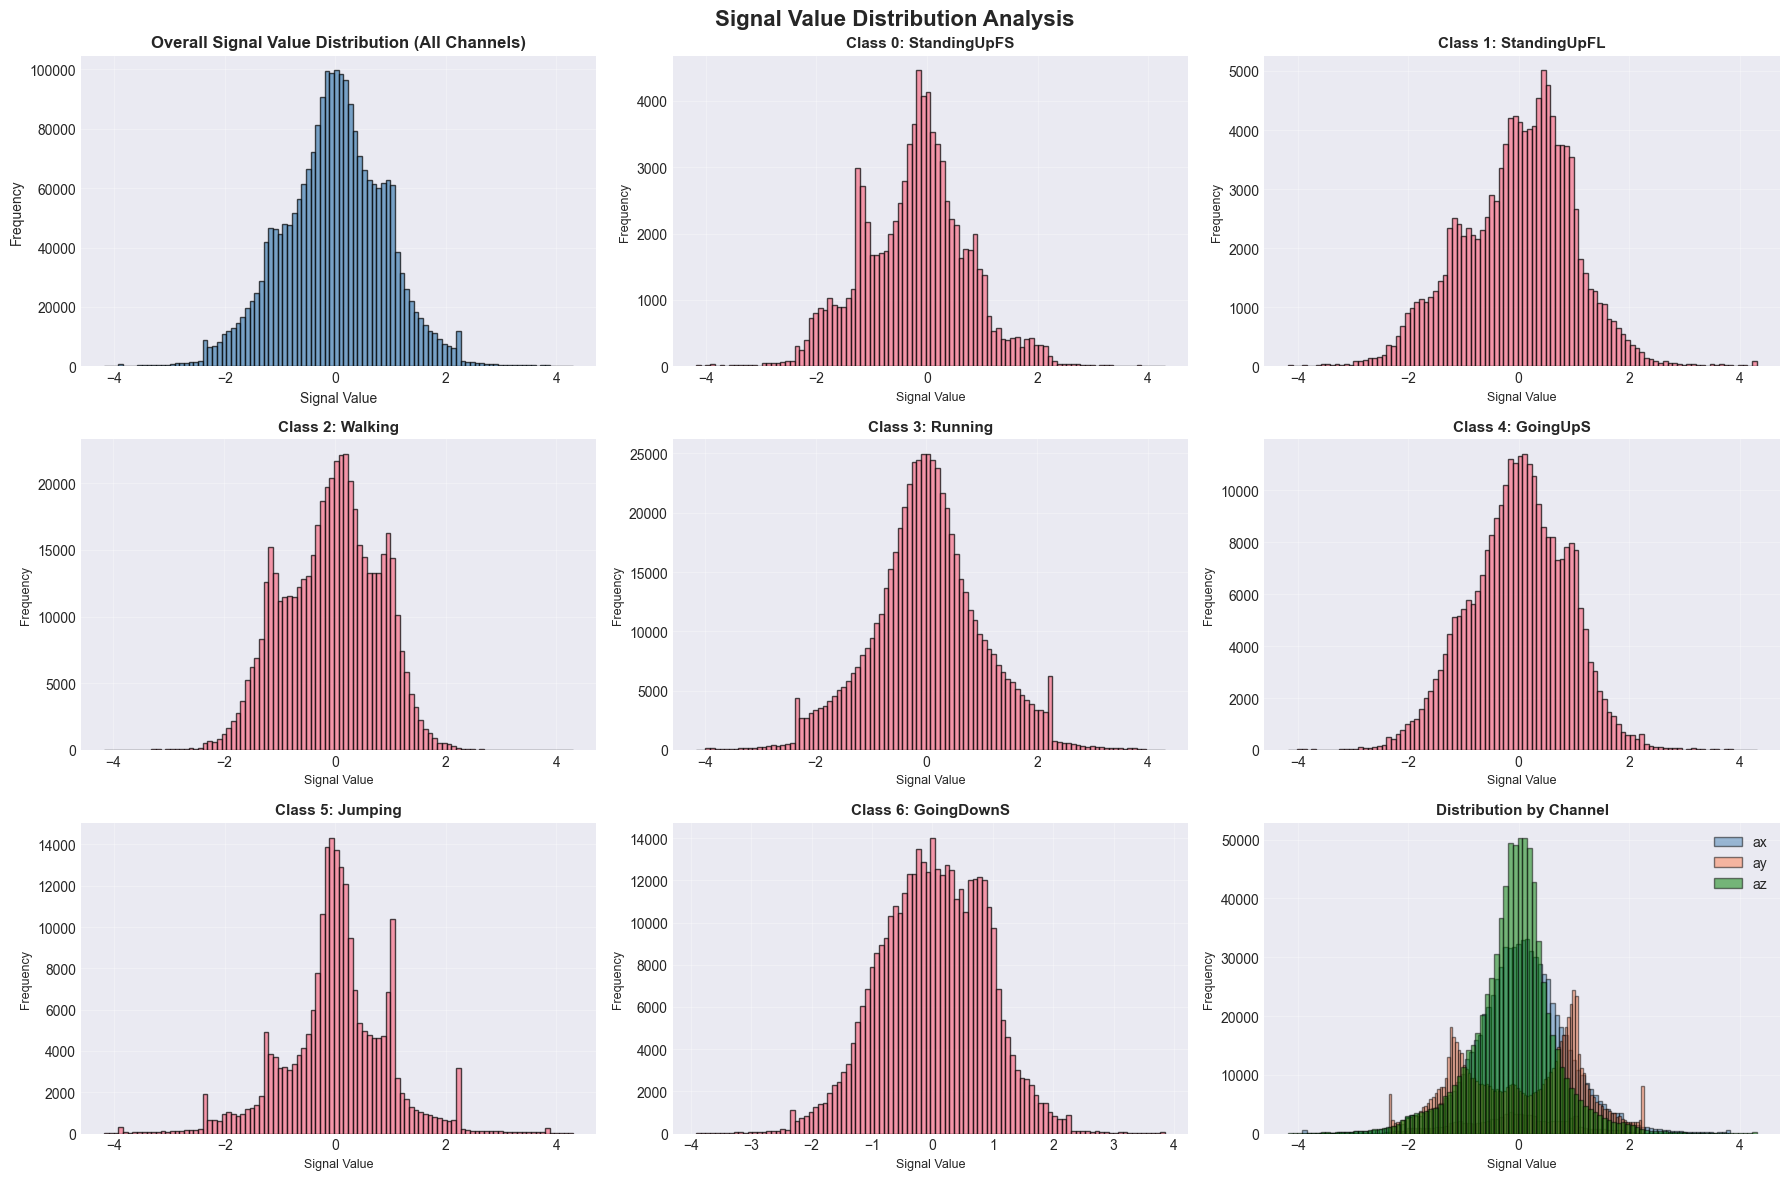

In [33]:
# Distribution of signal values
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

# Overall distribution (all channels combined)
axes[0].hist(train_signals.flatten(), bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title('Overall Signal Value Distribution (All Channels)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Signal Value', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Distribution by class (all channels)
for class_id in range(8):  # 0-7, last subplot is for per-channel
    class_indices = np.where(train_labels == class_id)[0]
    if len(class_indices) > 0:
        class_signals = train_signals[class_indices].flatten()
        axes[class_id + 1].hist(class_signals, bins=100, alpha=0.7, edgecolor='black')
        axes[class_id + 1].set_title(f'Class {class_id}: {CLASS_NAMES[class_id]}', fontsize=11, fontweight='bold')
        axes[class_id + 1].set_xlabel('Signal Value', fontsize=9)
        axes[class_id + 1].set_ylabel('Frequency', fontsize=9)
        axes[class_id + 1].grid(True, alpha=0.3)

# Per-channel distribution in last subplot
axes[8].hist(train_signals[:, 0, :].flatten(), bins=100, alpha=0.5, label='ax', color='steelblue', edgecolor='black')
axes[8].hist(train_signals[:, 1, :].flatten(), bins=100, alpha=0.5, label='ay', color='coral', edgecolor='black')
axes[8].hist(train_signals[:, 2, :].flatten(), bins=100, alpha=0.5, label='az', color='green', edgecolor='black')
axes[8].set_title('Distribution by Channel', fontsize=11, fontweight='bold')
axes[8].set_xlabel('Signal Value', fontsize=9)
axes[8].set_ylabel('Frequency', fontsize=9)
axes[8].legend()
axes[8].grid(True, alpha=0.3)

plt.suptitle('Signal Value Distribution Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Signal Characteristics Analysis


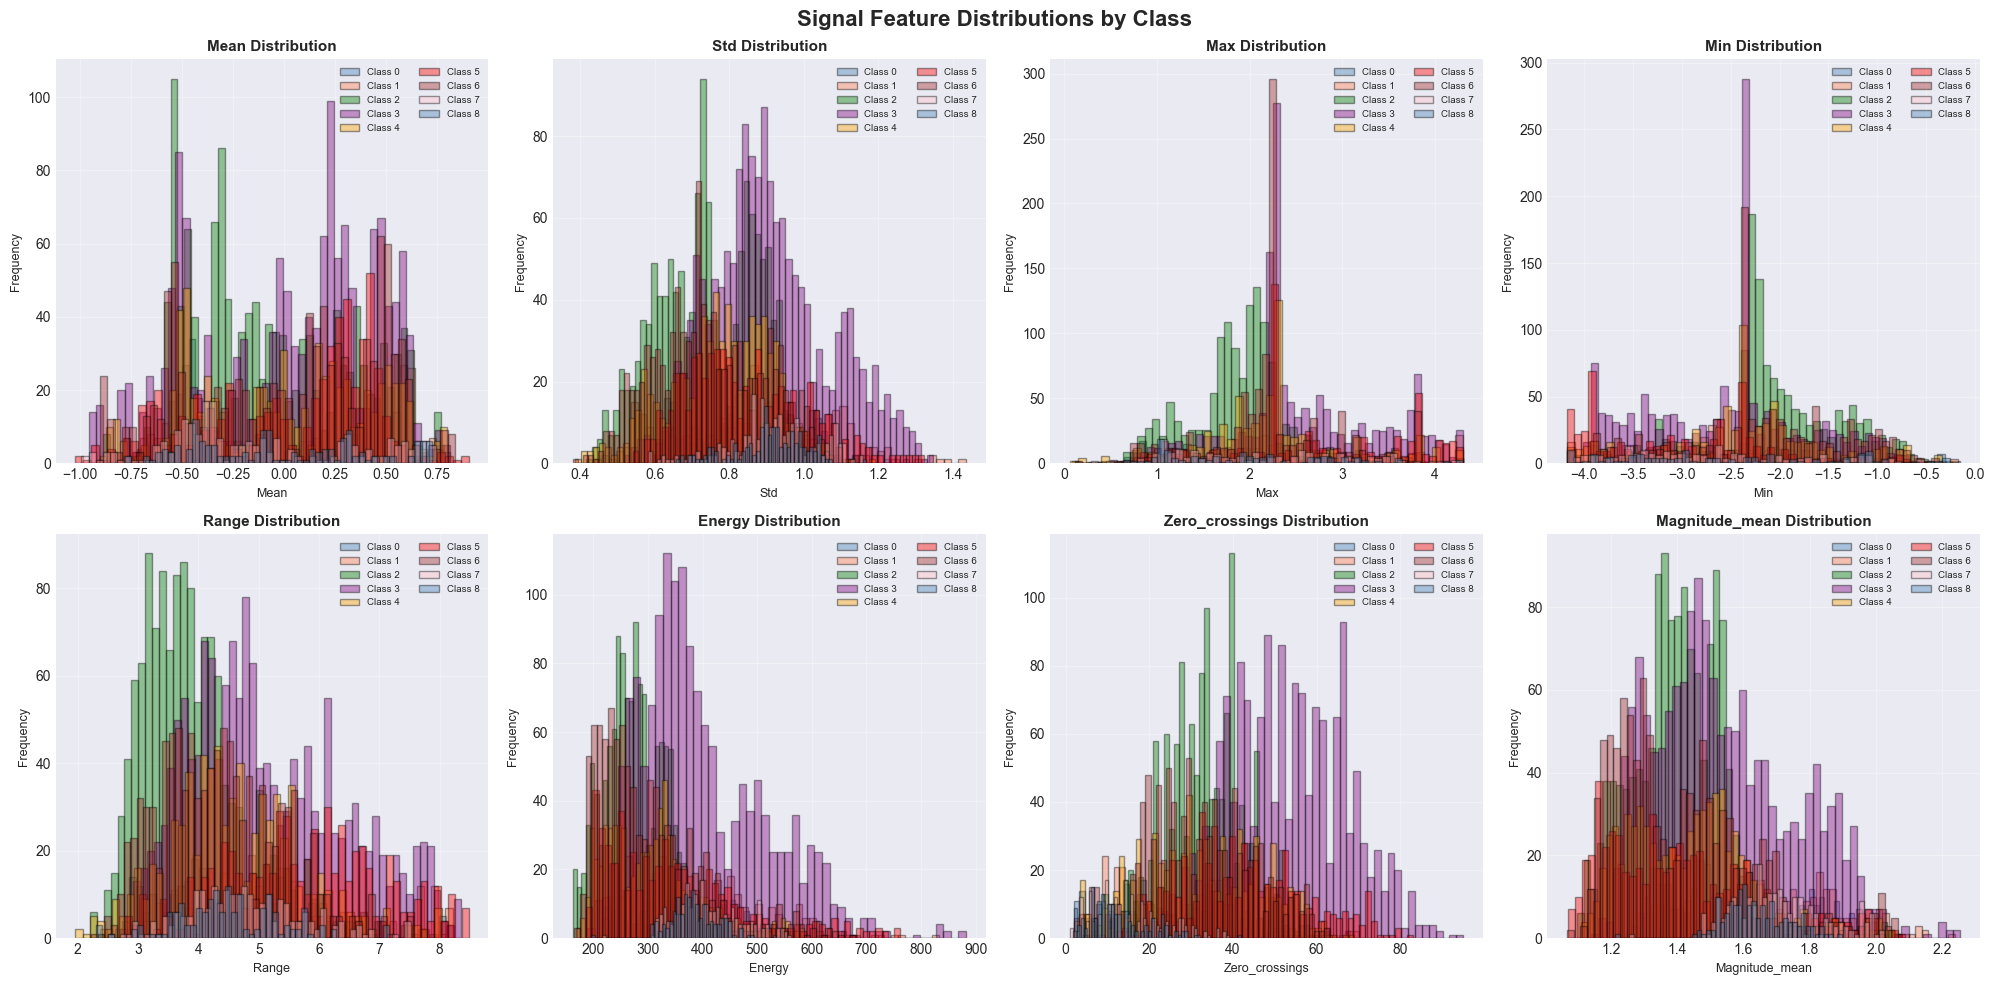

In [34]:
# Calculate signal characteristics for each sample
def calculate_signal_features(signals):
    """Calculate various features for each signal"""
    n_samples = signals.shape[0]
    features = {
        'mean': np.mean(signals, axis=(1, 2)),  # Mean across channels and time
        'std': np.std(signals, axis=(1, 2)),
        'max': np.max(signals, axis=(1, 2)),
        'min': np.min(signals, axis=(1, 2)),
        'range': np.max(signals, axis=(1, 2)) - np.min(signals, axis=(1, 2)),
        'energy': np.sum(signals**2, axis=(1, 2)),
        'zero_crossings': np.zeros(n_samples),
        'magnitude_mean': np.zeros(n_samples)  # Mean magnitude across time
    }
    
    # Calculate zero crossings and magnitude for each sample
    for i in range(n_samples):
        signal = signals[i]  # Shape: (3, 128)
        # Zero crossings: count sign changes in each channel, sum
        zc = 0
        for ch in range(3):
            zc += len(np.where(np.diff(np.signbit(signal[ch])))[0])
        features['zero_crossings'][i] = zc
        
        # Magnitude: sqrt(ax^2 + ay^2 + az^2) for each timestep, then mean
        magnitude = np.sqrt(signal[0]**2 + signal[1]**2 + signal[2]**2)
        features['magnitude_mean'][i] = magnitude.mean()
    
    return features

# Calculate features for train set
train_features = calculate_signal_features(train_signals)

# Visualize feature distributions by class
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

feature_names = ['mean', 'std', 'max', 'min', 'range', 'energy', 'zero_crossings', 'magnitude_mean']
colors = ['steelblue', 'coral', 'green', 'purple', 'orange', 'red', 'brown', 'pink']

for i, feature_name in enumerate(feature_names):
    for class_id in range(9):
        class_indices = np.where(train_labels == class_id)[0]
        if len(class_indices) > 0:
            feature_values = train_features[feature_name][class_indices]
            axes[i].hist(feature_values, bins=50, alpha=0.4, label=f'Class {class_id}', 
                        color=colors[class_id % len(colors)], edgecolor='black')
    
    axes[i].set_title(f'{feature_name.capitalize()} Distribution', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feature_name.capitalize(), fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].legend(fontsize=7, ncol=2)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Signal Feature Distributions by Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


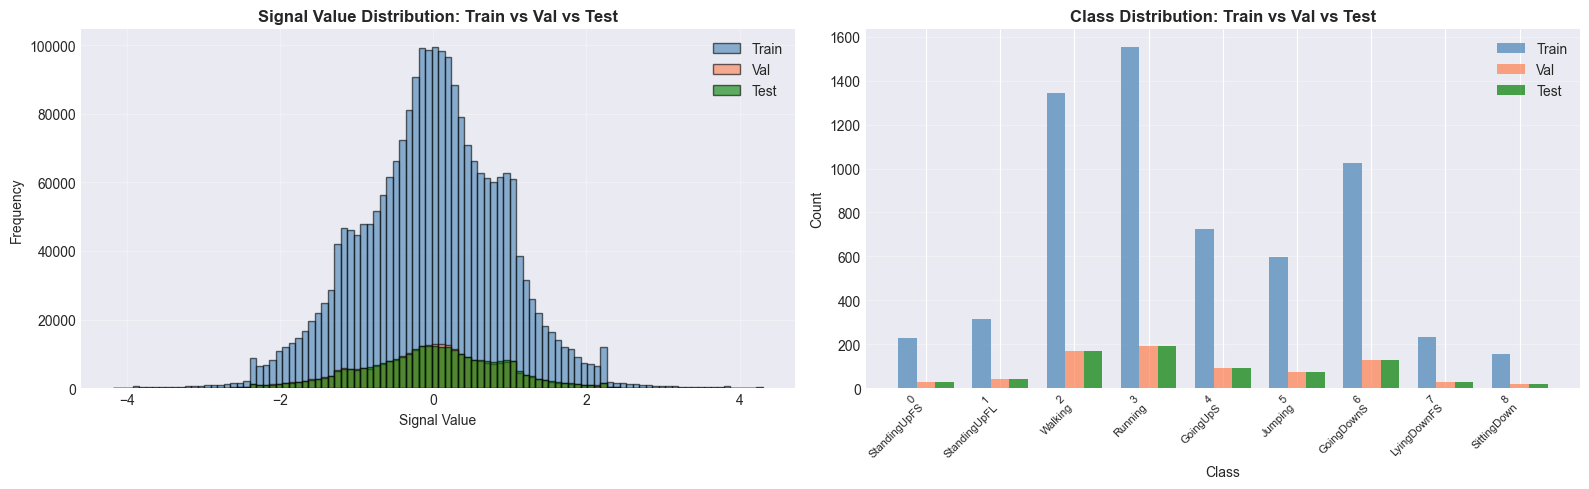

In [35]:
# Compare train, val, and test distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Signal value distribution comparison
axes[0].hist(train_signals.flatten(), bins=100, alpha=0.6, label='Train', color='steelblue', edgecolor='black')
axes[0].hist(val_signals.flatten(), bins=100, alpha=0.6, label='Val', color='coral', edgecolor='black')
axes[0].hist(test_signals.flatten(), bins=100, alpha=0.6, label='Test', color='green', edgecolor='black')
axes[0].set_title('Signal Value Distribution: Train vs Val vs Test', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Signal Value', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Class distribution comparison
train_counts = pd.Series(train_labels).value_counts().sort_index()
val_counts = pd.Series(val_labels).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

x = np.arange(len(train_counts))
width = 0.25
axes[1].bar(x - width, train_counts.values, width, label='Train', color='steelblue', alpha=0.7)
axes[1].bar(x, val_counts.values, width, label='Val', color='coral', alpha=0.7)
axes[1].bar(x + width, test_counts.values, width, label='Test', color='green', alpha=0.7)
axes[1].set_title('Class Distribution: Train vs Val vs Test', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=10)
axes[1].set_ylabel('Count', fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in train_counts.index], rotation=45, ha='right', fontsize=8)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Sequence Length Analysis


SEQUENCE LENGTH ANALYSIS

Train set sequence lengths:
  Min: 151
  Max: 151
  Mean: 151.00
  Median: 151.00
  Std: 0.00

Val set sequence lengths:
  Min: 151
  Max: 151
  Mean: 151.00
  Median: 151.00
  Std: 0.00

Test set sequence lengths:
  Min: 151
  Max: 151
  Mean: 151.00
  Median: 151.00
  Std: 0.00


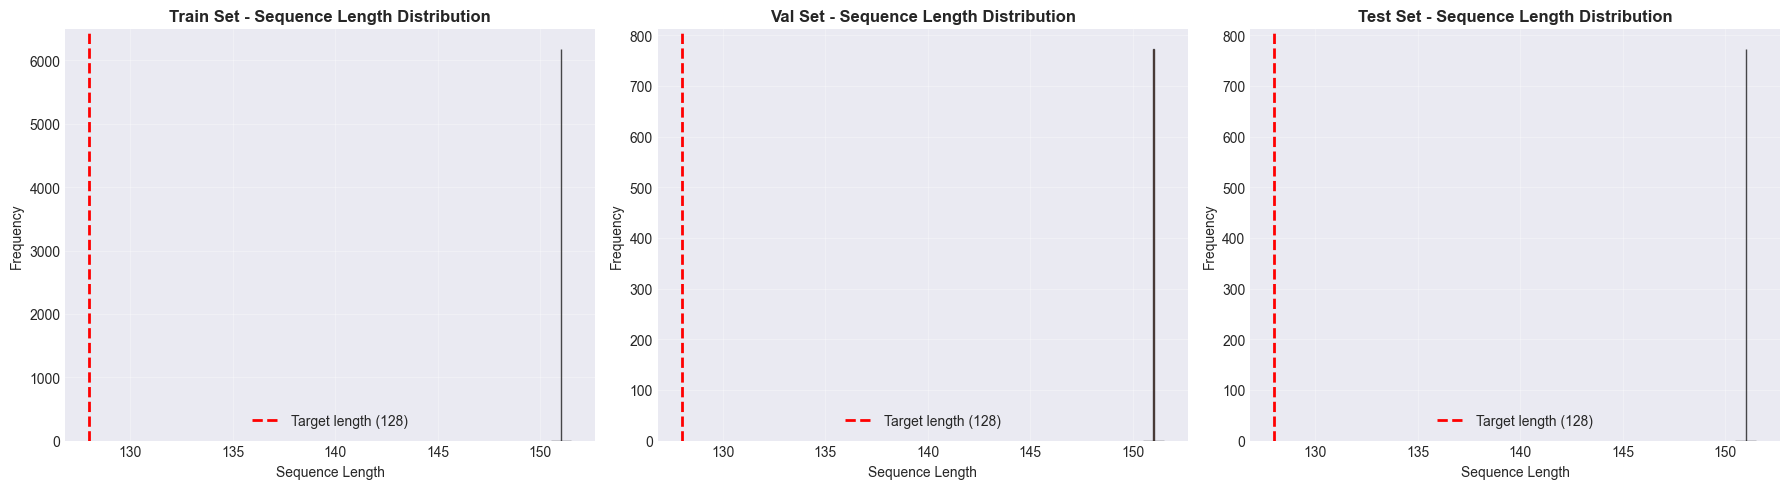

In [36]:
# Analyze original sequence lengths before padding/truncation
print("=" * 60)
print("SEQUENCE LENGTH ANALYSIS")
print("=" * 60)

def get_sequence_lengths(df):
    """Get sequence lengths for each ID"""
    grouped = df.groupby('ID')
    lengths = []
    for id_val, group in grouped:
        lengths.append(len(group))
    return np.array(lengths)

train_lengths = get_sequence_lengths(unimib_train)
val_lengths = get_sequence_lengths(unimib_val)
test_lengths = get_sequence_lengths(unimib_test)

print(f"\nTrain set sequence lengths:")
print(f"  Min: {train_lengths.min()}")
print(f"  Max: {train_lengths.max()}")
print(f"  Mean: {train_lengths.mean():.2f}")
print(f"  Median: {np.median(train_lengths):.2f}")
print(f"  Std: {train_lengths.std():.2f}")

print(f"\nVal set sequence lengths:")
print(f"  Min: {val_lengths.min()}")
print(f"  Max: {val_lengths.max()}")
print(f"  Mean: {val_lengths.mean():.2f}")
print(f"  Median: {np.median(val_lengths):.2f}")
print(f"  Std: {val_lengths.std():.2f}")

print(f"\nTest set sequence lengths:")
print(f"  Min: {test_lengths.min()}")
print(f"  Max: {test_lengths.max()}")
print(f"  Mean: {test_lengths.mean():.2f}")
print(f"  Median: {np.median(test_lengths):.2f}")
print(f"  Std: {test_lengths.std():.2f}")

# Visualize sequence length distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(train_lengths, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(128, color='red', linestyle='--', linewidth=2, label='Target length (128)')
axes[0].set_title('Train Set - Sequence Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sequence Length', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(val_lengths, bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(128, color='red', linestyle='--', linewidth=2, label='Target length (128)')
axes[1].set_title('Val Set - Sequence Length Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sequence Length', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(test_lengths, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[2].axvline(128, color='red', linestyle='--', linewidth=2, label='Target length (128)')
axes[2].set_title('Test Set - Sequence Length Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Sequence Length', fontsize=10)
axes[2].set_ylabel('Frequency', fontsize=10)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Summary & Key Findings


In [37]:
# Create summary report
print("=" * 60)
print("DATASET EXPLORATION SUMMARY")
print("=" * 60)

print("\n1. UNIMIB SHAR DATASET:")
print(f"   - Train samples: {len(train_signals):,}")
print(f"   - Val samples: {len(val_signals):,}")
print(f"   - Test samples: {len(test_signals):,}")
print(f"   - Signal shape: (3 channels, 128 timesteps)")
print(f"   - Number of classes: 9")
print(f"   - Channels: ax (x-axis), ay (y-axis), az (z-axis) accelerometer")

print("\n2. CLASS DISTRIBUTION (Train):")
for class_id in sorted(train_class_counts.index):
    count = train_class_counts[class_id]
    percentage = (count / len(train_labels)) * 100
    print(f"   - Class {class_id} ({CLASS_NAMES[class_id]}): {count:,} ({percentage:.2f}%)")

print("\n3. DATA QUALITY:")
print(f"   - Missing values in train: {np.isnan(train_signals).sum()}")
print(f"   - Missing values in val: {np.isnan(val_signals).sum()}")
print(f"   - Missing values in test: {np.isnan(test_signals).sum()}")

print("\n4. SIGNAL CHARACTERISTICS:")
print(f"   - Signal range (train): [{train_signals.min():.4f}, {train_signals.max():.4f}]")
print(f"   - Mean (train): {train_signals.mean():.4f}, Std: {train_signals.std():.4f}")
print(f"   - Per-channel means: ax={train_signals[:, 0, :].mean():.4f}, "
      f"ay={train_signals[:, 1, :].mean():.4f}, az={train_signals[:, 2, :].mean():.4f}")

print("\n5. SEQUENCE LENGTH:")
print(f"   - Target length: 128 timesteps")
print(f"   - Original lengths - Min: {train_lengths.min()}, Max: {train_lengths.max()}, "
      f"Mean: {train_lengths.mean():.2f}")

print("\n6. CLASS IMBALANCE:")
class_percentages = [(count / len(train_labels)) * 100 for count in train_class_counts.values]
max_pct = max(class_percentages)
min_pct = min(class_percentages)
imbalance_ratio = max_pct / min_pct if min_pct > 0 else float('inf')
print(f"   - Most common class: {max_pct:.2f}%")
print(f"   - Least common class: {min_pct:.2f}%")
print(f"   - Imbalance ratio: {imbalance_ratio:.2f}x")

print("\n" + "=" * 60)


DATASET EXPLORATION SUMMARY

1. UNIMIB SHAR DATASET:
   - Train samples: 6,180
   - Val samples: 773
   - Test samples: 773
   - Signal shape: (3 channels, 128 timesteps)
   - Number of classes: 9
   - Channels: ax (x-axis), ay (y-axis), az (z-axis) accelerometer

2. CLASS DISTRIBUTION (Train):
   - Class 0 (StandingUpFS): 228 (3.69%)
   - Class 1 (StandingUpFL): 317 (5.13%)
   - Class 2 (Walking): 1,342 (21.72%)
   - Class 3 (Running): 1,556 (25.18%)
   - Class 4 (GoingUpS): 726 (11.75%)
   - Class 5 (Jumping): 597 (9.66%)
   - Class 6 (GoingDownS): 1,024 (16.57%)
   - Class 7 (LyingDownFS): 233 (3.77%)
   - Class 8 (SittingDown): 157 (2.54%)

3. DATA QUALITY:
   - Missing values in train: 0
   - Missing values in val: 0
   - Missing values in test: 0

4. SIGNAL CHARACTERISTICS:
   - Signal range (train): [-4.1779, 4.3034]
   - Mean (train): -0.0216, Std: 0.9401
   - Per-channel means: ax=0.0319, ay=-0.0044, az=-0.0921

5. SEQUENCE LENGTH:
   - Target length: 128 timesteps
   - Origin